In [3]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [4]:
RAW_DIR = Path("../data/raw")

csv_files = list(RAW_DIR.glob("*.csv"))

print(f"Total commodity files: {len(csv_files)}")

Total commodity files: 325


In [6]:
file_summary = []

for file in csv_files:
    if file.stat().st_size == 0:
        print(f"Skipping empty file: {file.name}")
        continue

    try:
        df = pd.read_csv(file, encoding="utf-8-sig", on_bad_lines="skip")
    except pd.errors.EmptyDataError:
        print(f"Skipping empty CSV file: {file.name}")
        continue
    except Exception as e:
        print(f"Skipping unreadable file {file.name}: {e}")
        continue

    file_summary.append({
        "Commodity": file.stem,
        "Rows": len(df),
        "Columns": len(df.columns),
        "Missing Values": df.isna().sum().sum()
    })

summary_df = pd.DataFrame(file_summary)

summary_df = summary_df.sort_values(
    "Rows",
    ascending=False
).reset_index(drop=True)

display(summary_df.head(30))

Skipping empty CSV file: Betelnuts.csv
Skipping empty CSV file: Broomstick(Flower Broom).csv
Skipping empty CSV file: Camel Hair.csv
Skipping empty CSV file: Fig(Anjura-Anjeer).csv
Skipping empty CSV file: Goat Hair.csv
Skipping empty CSV file: Jaggery.csv
Skipping empty CSV file: Ladies Finger.csv
Skipping empty CSV file: Nargasi.csv
Skipping empty CSV file: Saffron.csv
Skipping empty CSV file: Seegu.csv


,Commodity,Rows,Columns,Missing Values
0,Potato,2764987,10,10
1,Onion,2624379,10,46
2,Wheat,2593767,10,6
3,Tomato,2338352,10,26
4,Paddy(Dhan)(Common),2160970,10,186
5,Brinjal,1784077,10,26
6,Green Chilli,1673213,10,24
7,Rice,1436499,10,6
8,Cauliflower,1422379,10,5
9,Banana,1257376,10,1


In [7]:
print("Total commodities:", len(summary_df))
print("Total rows:", f"{summary_df['Rows'].sum():,}")

display(summary_df.describe())

Total commodities: 315
Total rows: 56,879,072


,Rows,Columns,Missing Values
count,3.150000e+02,315.0,315.000000
mean,1.805685e+05,10.0,3.619048
std,4.162537e+05,0.0,17.810600
min,2.000000e+00,10.0,0.000000
25%,3.570500e+03,10.0,0.000000
50%,1.681600e+04,10.0,0.000000
75%,1.241240e+05,10.0,0.000000
max,2.764987e+06,10.0,212.000000


In [9]:
schema_summary = {}

for file in csv_files:
    if file.stat().st_size == 0:
        continue

    try:
        temp = pd.read_csv(
            file,
            nrows=1,
            encoding="utf-8-sig",
            on_bad_lines="skip"
        )

        schema = tuple(temp.columns)

        schema_summary.setdefault(schema, []).append(file.stem)

    except Exception:
        continue


print("Different schemas found:", len(schema_summary))

for i, (schema, commodities) in enumerate(schema_summary.items(), start=1):
    print(f"\nSchema {i} — {len(commodities)} files")
    print(schema)

Different schemas found: 2

Schema 1 — 293 files
('State Name', 'District Name', 'Market Name', 'Variety', 'Group', 'Arrivals (Tonnes)', 'Min Price (Rs./Quintal)', 'Max Price (Rs./Quintal)', 'Modal Price (Rs./Quintal)', 'Reported Date')

Schema 2 — 22 files
('State Name', 'District Name', 'Market Name', 'Variety', 'Group', 'Arrivals', 'Min Price', 'Max Price', 'Modal Price', 'Reported Date')


In [10]:
schema_files = []

for file in csv_files:
    if file.stat().st_size == 0:
        continue

    try:
        temp = pd.read_csv(
            file,
            nrows=1,
            encoding="utf-8-sig",
            on_bad_lines="skip"
        )

        if "Arrivals" in temp.columns and "Arrivals (Tonnes)" not in temp.columns:
            schema_files.append(file.stem)

    except Exception:
        continue

print(f"Files using the alternate schema: {len(schema_files)}")
print(schema_files)

Files using the alternate schema: 22
['Alasande Gram', 'Amphophalus', 'Apple', 'Astera', 'Banana', 'Beetroot', 'Bran', 'Broken Rice', 'Cabbage', 'Coconut Oil', 'Egg', 'Ginger(Green)', 'Green Peas', 'Guava', 'Indian Beans (Seam)', 'Kakada', 'Lak(Teora)', 'Marasebu', 'Mustard', 'Paddy(Dhan)(Common)', 'Soanf', 'Spinach']


In [11]:
sample = pd.read_csv(
    csv_files[0],
    nrows=1000,
    encoding="utf-8-sig",
    on_bad_lines="skip"
)

print(sample.dtypes)
display(sample.head())

State Name                       str
District Name                    str
Market Name                      str
Variety                          str
Group                            str
Arrivals (Tonnes)            float64
Min Price (Rs./Quintal)      float64
Max Price (Rs./Quintal)      float64
Modal Price (Rs./Quintal)    float64
Reported Date                    str
dtype: object


,State Name,District Name,Market Name,Variety,Group,Arrivals (Tonnes),Min Price (Rs./Quintal),Max Price (Rs./Quintal),Modal Price (Rs./Quintal),Reported Date
0,Andhra Pradesh,Kurnool,Adoni,Other,Spices,3.0,2811.0,2811.0,2811.0,2005-03-24
1,Andhra Pradesh,Kurnool,Adoni,Other,Spices,16.0,2800.0,3350.0,3211.0,2005-03-29
2,Andhra Pradesh,Kurnool,Adoni,Other,Spices,6.0,1300.0,3209.0,2700.0,2005-03-30
3,Andhra Pradesh,Kurnool,Adoni,Other,Spices,2.0,3419.0,3419.0,3419.0,2005-04-04
4,Andhra Pradesh,Kurnool,Adoni,Other,Spices,2.0,3001.0,3001.0,3001.0,2005-04-07


In [12]:
# Inspect a sample from every non-empty commodity file

sample_results = []

for file in csv_files:
    if file.stat().st_size == 0:
        continue

    try:
        df = pd.read_csv(
            file,
            nrows=1000,
            encoding="utf-8-sig",
            on_bad_lines="skip"
        )

        # Normalize the two possible arrival column names
        if "Arrivals (Tonnes)" in df.columns:
            arrival_col = "Arrivals (Tonnes)"
        elif "Arrivals" in df.columns:
            arrival_col = "Arrivals"
        else:
            arrival_col = None

        sample_results.append({
            "Commodity": file.stem,
            "Rows Sampled": len(df),
            "Arrival Column": arrival_col,
            "Date Type": str(df["Reported Date"].dtype),
            "Missing Modal Price": df[
                "Modal Price (Rs./Quintal)"
                if "Modal Price (Rs./Quintal)" in df.columns
                else "Modal Price"
            ].isna().sum()
        })

    except Exception as e:
        print(f"Could not inspect {file.name}: {e}")

quality_df = pd.DataFrame(sample_results)

display(quality_df.head(30))

Could not inspect Betelnuts.csv: No columns to parse from file
Could not inspect Broomstick(Flower Broom).csv: No columns to parse from file
Could not inspect Camel Hair.csv: No columns to parse from file
Could not inspect Fig(Anjura-Anjeer).csv: No columns to parse from file
Could not inspect Goat Hair.csv: No columns to parse from file
Could not inspect Jaggery.csv: No columns to parse from file
Could not inspect Ladies Finger.csv: No columns to parse from file
Could not inspect Nargasi.csv: No columns to parse from file
Could not inspect Saffron.csv: No columns to parse from file
Could not inspect Seegu.csv: No columns to parse from file


,Commodity,Rows Sampled,Arrival Column,Date Type,Missing Modal Price
0,Ajwan,1000,Arrivals (Tonnes),str,8
1,Alasande Gram,1000,Arrivals,str,0
2,Almond(Badam),1000,Arrivals (Tonnes),str,0
3,Alsandikai,1000,Arrivals (Tonnes),str,0
4,Amaranthus,1000,Arrivals (Tonnes),str,1
5,Ambada Seed,363,Arrivals (Tonnes),str,0
6,Amla(Nelli Kai),1000,Arrivals (Tonnes),str,0
7,Amphophalus,1000,Arrivals,str,0
8,Antawala,1000,Arrivals (Tonnes),str,0
9,Anthorium,1000,Arrivals (Tonnes),str,0


In [13]:
print("Files successfully inspected:", len(quality_df))

print("\nArrival column distribution:")
display(quality_df["Arrival Column"].value_counts())

print("\nDate types:")
display(quality_df["Date Type"].value_counts())

print("\nFiles with missing modal prices in sample:")
display(
    quality_df[quality_df["Missing Modal Price"] > 0]
    [["Commodity", "Missing Modal Price"]]
    .head(20)
)

Files successfully inspected: 315

Arrival column distribution:


Arrival Column
Arrivals (Tonnes)    293
Arrivals              22
Name: count, dtype: int64


Date types:


Date Type
str    315
Name: count, dtype: int64


Files with missing modal prices in sample:


,Commodity,Missing Modal Price
0,Ajwan,8
4,Amaranthus,1
25,Beans,8
67,Chili Red,1
77,Cocoa,1
83,Copra,5
87,Cotton,1
89,Cowpea (Lobia-Karamani),1
100,Dry Chillies,7
136,Groundnut,1


In [14]:
# Check and normalize column names across all usable commodity files

STANDARD_COLUMNS = {
    "Arrivals": "Arrivals (Tonnes)",
    "Min Price": "Min Price (Rs./Quintal)",
    "Max Price": "Max Price (Rs./Quintal)",
    "Modal Price": "Modal Price (Rs./Quintal)"
}

normalized_files = []
failed_files = []

for file in csv_files:
    if file.stat().st_size == 0:
        continue

    try:
        df = pd.read_csv(
            file,
            nrows=0,
            encoding="utf-8-sig",
            on_bad_lines="skip"
        )

        rename_map = {}

        for old_name, new_name in STANDARD_COLUMNS.items():
            if old_name in df.columns:
                rename_map[old_name] = new_name

        normalized_columns = df.rename(columns=rename_map).columns.tolist()

        normalized_files.append({
            "Commodity": file.stem,
            "Columns": normalized_columns
        })

    except Exception as e:
        failed_files.append({
            "File": file.name,
            "Error": str(e)
        })

print(f"Files successfully checked: {len(normalized_files)}")
print(f"Files that failed: {len(failed_files)}")

if failed_files:
    display(pd.DataFrame(failed_files))

Files successfully checked: 315
Files that failed: 10


,File,Error
0,Betelnuts.csv,No columns to parse from file
1,Broomstick(Flower Broom).csv,No columns to parse from file
2,Camel Hair.csv,No columns to parse from file
3,Fig(Anjura-Anjeer).csv,No columns to parse from file
4,Goat Hair.csv,No columns to parse from file
5,Jaggery.csv,No columns to parse from file
6,Ladies Finger.csv,No columns to parse from file
7,Nargasi.csv,No columns to parse from file
8,Saffron.csv,No columns to parse from file
9,Seegu.csv,No columns to parse from file


In [15]:
# Check date and numeric columns using a sample of each commodity

quality_results = []

for file in csv_files:
    if file.stat().st_size == 0:
        continue

    try:
        df = pd.read_csv(
            file,
            nrows=5000,
            encoding="utf-8-sig",
            on_bad_lines="skip"
        )

        # Normalize alternate column names
        df = df.rename(columns={
            "Arrivals": "Arrivals (Tonnes)",
            "Min Price": "Min Price (Rs./Quintal)",
            "Max Price": "Max Price (Rs./Quintal)",
            "Modal Price": "Modal Price (Rs./Quintal)"
        })

        numeric_cols = [
            "Arrivals (Tonnes)",
            "Min Price (Rs./Quintal)",
            "Max Price (Rs./Quintal)",
            "Modal Price (Rs./Quintal)"
        ]

        for col in numeric_cols:
            df[col] = pd.to_numeric(df[col], errors="coerce")

        dates = pd.to_datetime(
            df["Reported Date"],
            errors="coerce"
        )

        quality_results.append({
            "Commodity": file.stem,
            "Invalid Dates": dates.isna().sum(),
            "Invalid Arrivals": df["Arrivals (Tonnes)"].isna().sum(),
            "Invalid Modal Prices": df["Modal Price (Rs./Quintal)"].isna().sum(),
            "Negative Modal Prices": (
                df["Modal Price (Rs./Quintal)"] < 0
            ).sum(),
            "Rows Checked": len(df)
        })

    except Exception as e:
        print(f"Could not process {file.name}: {e}")

quality_df = pd.DataFrame(quality_results)

display(quality_df.head(20))

print("Total files checked:", len(quality_df))
print(
    "Files with invalid dates:",
    (quality_df["Invalid Dates"] > 0).sum()
)
print(
    "Files with invalid modal prices:",
    (quality_df["Invalid Modal Prices"] > 0).sum()
)

Could not process Betelnuts.csv: No columns to parse from file
Could not process Broomstick(Flower Broom).csv: No columns to parse from file
Could not process Camel Hair.csv: No columns to parse from file
Could not process Fig(Anjura-Anjeer).csv: No columns to parse from file
Could not process Goat Hair.csv: No columns to parse from file
Could not process Jaggery.csv: No columns to parse from file
Could not process Ladies Finger.csv: No columns to parse from file
Could not process Nargasi.csv: No columns to parse from file
Could not process Saffron.csv: No columns to parse from file
Could not process Seegu.csv: No columns to parse from file


,Commodity,Invalid Dates,Invalid Arrivals,Invalid Modal Prices,Negative Modal Prices,Rows Checked
0,Ajwan,0,0,8,0,5000
1,Alasande Gram,0,0,0,0,5000
2,Almond(Badam),0,0,0,0,1560
3,Alsandikai,0,0,0,0,5000
4,Amaranthus,0,0,1,0,5000
5,Ambada Seed,0,0,0,0,363
6,Amla(Nelli Kai),0,0,0,0,5000
7,Amphophalus,0,0,0,0,5000
8,Antawala,0,0,0,0,1422
9,Anthorium,0,0,0,0,3785


Total files checked: 315
Files with invalid dates: 24
Files with invalid modal prices: 29


EDA sample shape: (540616, 11)


,Arrivals (Tonnes),Min Price (Rs./Quintal),Max Price (Rs./Quintal),Modal Price (Rs./Quintal)
count,5.406160e+05,540614.000000,5.406030e+05,540545.000000
mean,6.523907e+02,4314.472221,5.364480e+03,4887.051080
std,9.851307e+03,10312.879162,2.168492e+04,11365.440605
min,0.000000e+00,0.000000,0.000000e+00,0.000000
25%,5.000000e-01,900.000000,1.200000e+03,1000.000000
50%,2.100000e+00,2000.000000,2.500000e+03,2250.000000
75%,1.300000e+01,3950.000000,4.800000e+03,4400.000000
max,5.682187e+06,695000.000000,1.300120e+07,700000.000000


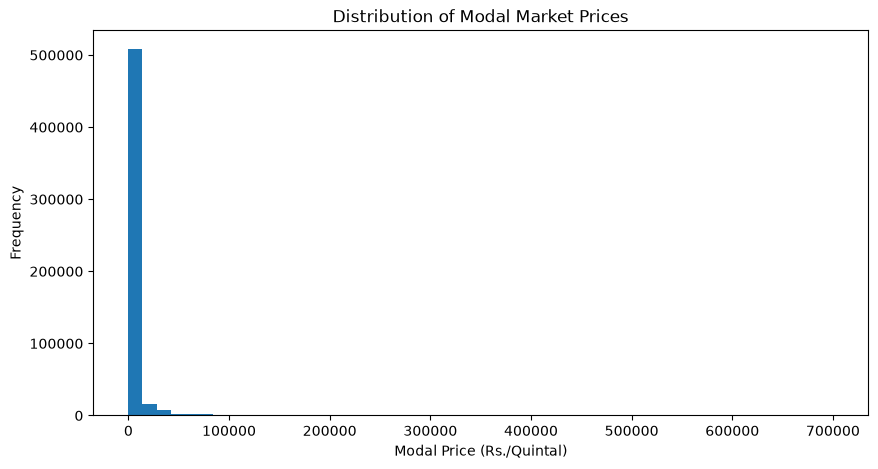

In [17]:
# Create a combined sample for exploratory analysis

eda_samples = []

for file in csv_files:
    if file.stat().st_size == 0:
        continue

    try:
        df = pd.read_csv(
            file,
            nrows=2000,
            encoding="utf-8-sig",
            on_bad_lines="skip"
        )

        df = df.rename(columns={
            "Arrivals": "Arrivals (Tonnes)",
            "Min Price": "Min Price (Rs./Quintal)",
            "Max Price": "Max Price (Rs./Quintal)",
            "Modal Price": "Modal Price (Rs./Quintal)"
        })

        df["Commodity"] = file.stem

        eda_samples.append(df)

    except Exception:
        continue

eda_df = pd.concat(
    eda_samples,
    ignore_index=True
)

print("EDA sample shape:", eda_df.shape)

display(
    eda_df[
        [
            "Commodity",
            "Arrivals (Tonnes)",
            "Min Price (Rs./Quintal)",
            "Max Price (Rs./Quintal)",
            "Modal Price (Rs./Quintal)"
        ]
    ].describe()
)
plt.figure(figsize=(10, 5))

plt.hist(
    eda_df["Modal Price (Rs./Quintal)"].dropna(),
    bins=50
)

plt.xlabel("Modal Price (Rs./Quintal)")
plt.ylabel("Frequency")
plt.title("Distribution of Modal Market Prices")

plt.show()

Earliest date: 2001-11-22 00:00:00
Latest date: 2024-02-01 00:00:00

Number of unique:
States: 33
Districts: 410
Markets: 1287
Commodities: 315

Top 20 markets by number of observations:


Market Name
Reasi                                               31239
Udhampur                                            25935
Flower Market,Gazipur                               15121
Jammu (Grain Mandi)                                 14268
Flower Market, Canaught Place(Pr. Yard,Mehrauli)    13380
Narwal Jammu (F&V)                                  12567
Gudimalkapur                                        11524
Binny Mill (F&V), Bangalore                         11324
Kathua                                               8366
Yemmiganur                                           7314
Ahmedabad                                            6777
Thattanchavady                                       6689
Narsingi                                             5904
Bangalore                                            5435
Mumbai                                               5391
Vadodara                                             4974
Bowenpally                                           4605
Ma

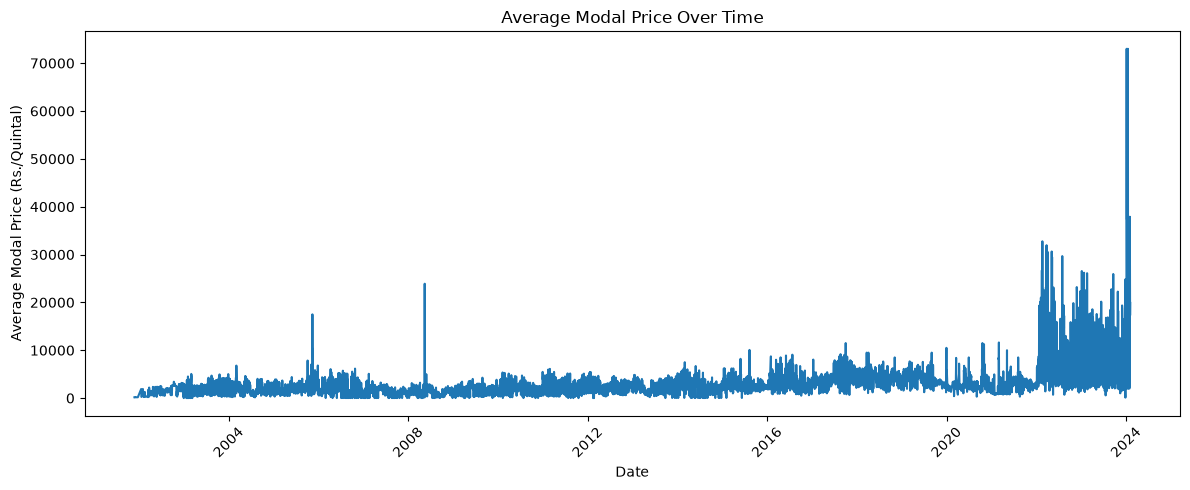

In [20]:
# Explore the time range and major markets in the sampled data

eda_df["Reported Date"] = pd.to_datetime(
    eda_df["Reported Date"],
    errors="coerce"
)

print("Earliest date:", eda_df["Reported Date"].min())
print("Latest date:", eda_df["Reported Date"].max())

print("\nNumber of unique:")
print("States:", eda_df["State Name"].nunique())
print("Districts:", eda_df["District Name"].nunique())
print("Markets:", eda_df["Market Name"].nunique())
print("Commodities:", eda_df["Commodity"].nunique())

print("\nTop 20 markets by number of observations:")

market_counts = (
    eda_df["Market Name"]
    .value_counts()
    .head(20)
)

display(market_counts)
plt.figure(figsize=(12, 5))

daily_prices = (
    eda_df
    .groupby("Reported Date")["Modal Price (Rs./Quintal)"]
    .mean()
)

plt.plot(
    daily_prices.index,
    daily_prices.values
)

plt.xlabel("Date")
plt.ylabel("Average Modal Price (Rs./Quintal)")
plt.title("Average Modal Price Over Time")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


In [21]:
print("========== KisanSetu Dataset Summary ==========\n")

print(f"Total CSV files found       : {len(csv_files)}")
print(f"Usable commodity files     : {len(summary_df)}")
print(f"Total available rows       : {summary_df['Rows'].sum():,}")

print("\nDataset structure:")
print("- Commodity-specific CSV files")
print("- Mandi/market-level observations")
print("- Daily reported market data")
print("- Prices reported per quintal")
print("- Arrivals reported as a market supply signal")

print("\nPrediction target:")
print("- Modal Price (Rs./Quintal)")

print("\nImportant input signals:")
print("- State")
print("- District")
print("- Market")
print("- Variety")
print("- Group")
print("- Arrivals")
print("- Historical prices")
print("- Reported Date")

print("\nData quality findings:")
print("- 10 files are empty and will be excluded.")
print("- 315 commodity files contain usable data.")
print("- Two column naming conventions exist and will be normalized.")
print("- Numeric and date fields require cleaning before modeling.")

print("\nNext notebook:")
print("02_data_preprocessing.ipynb")

========== KisanSetu Dataset Summary ==========

Total CSV files found       : 325
Usable commodity files     : 315
Total available rows       : 56,879,072

Dataset structure:
- Commodity-specific CSV files
- Mandi/market-level observations
- Daily reported market data
- Prices reported per quintal
- Arrivals reported as a market supply signal

Prediction target:
- Modal Price (Rs./Quintal)

Important input signals:
- State
- District
- Market
- Variety
- Group
- Arrivals
- Historical prices
- Reported Date

Data quality findings:
- 10 files are empty and will be excluded.
- 315 commodity files contain usable data.
- Two column naming conventions exist and will be normalized.
- Numeric and date fields require cleaning before modeling.

Next notebook:
02_data_preprocessing.ipynb
